Dropping: 52W L


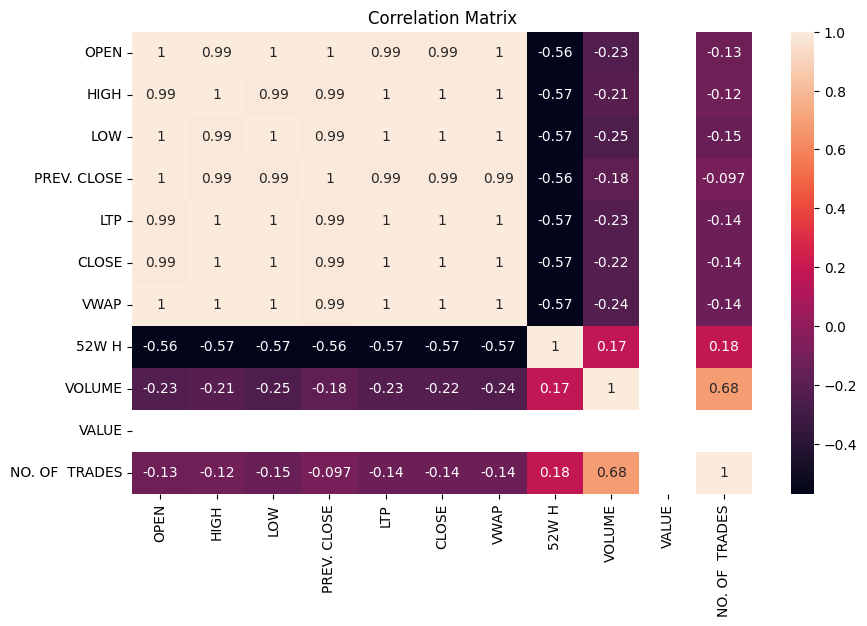

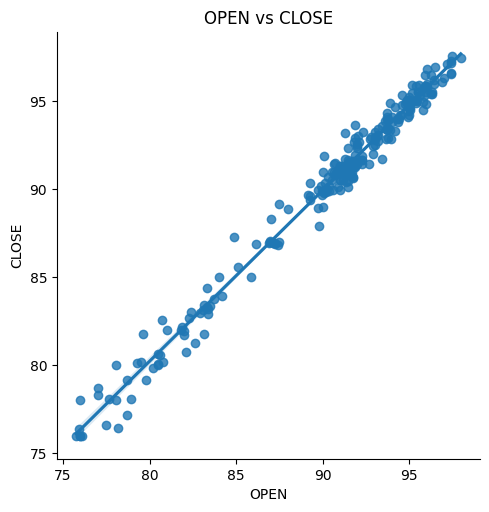

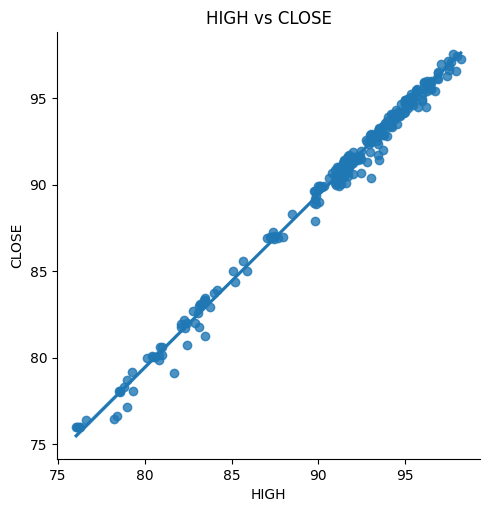

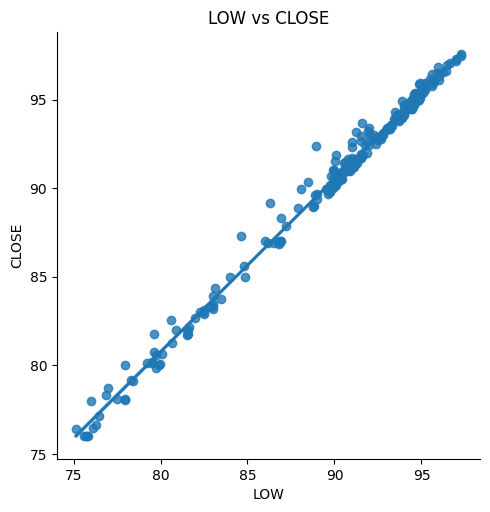

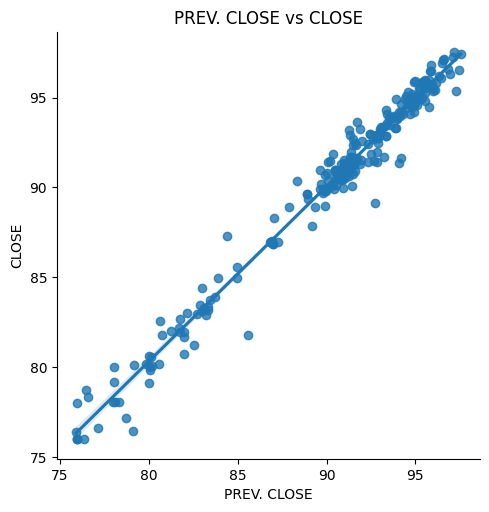

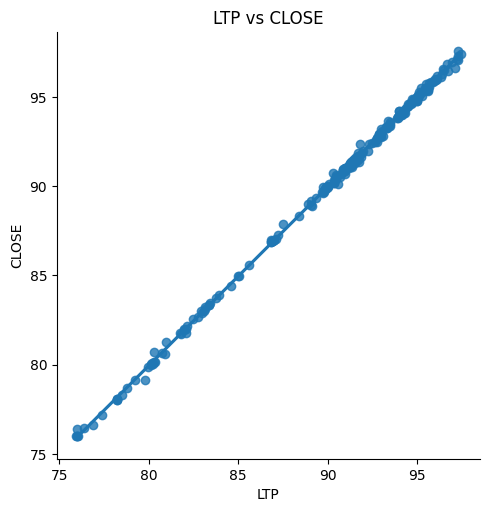

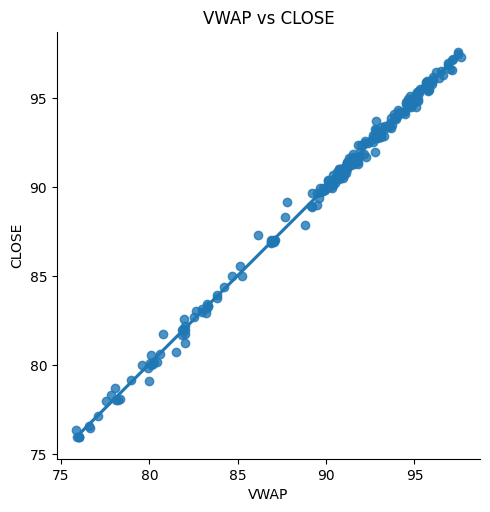

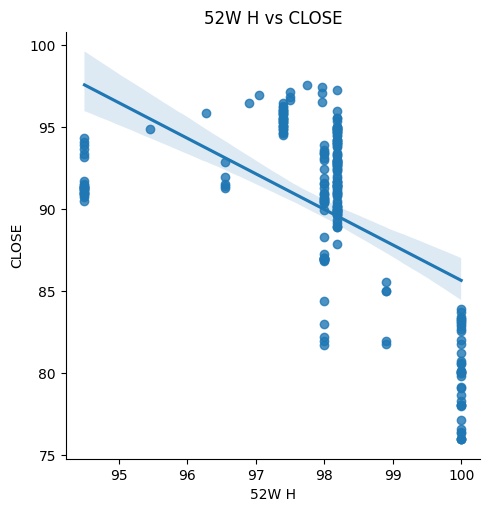

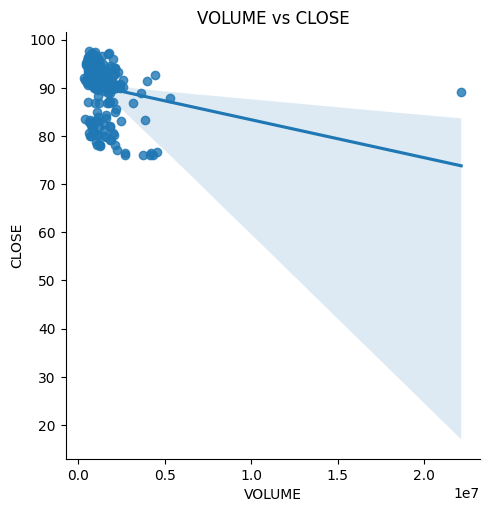

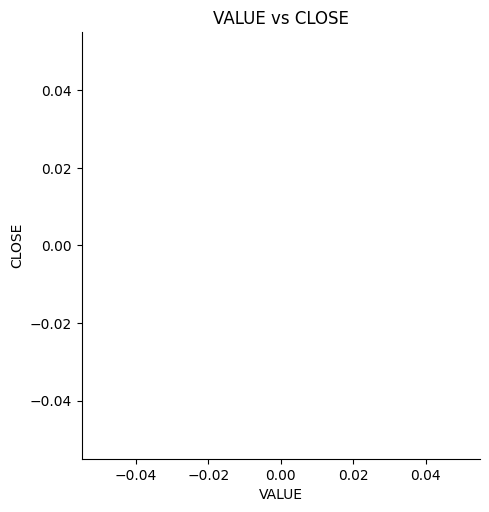

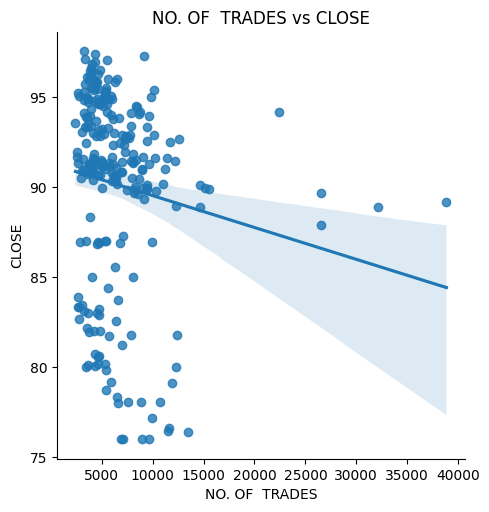

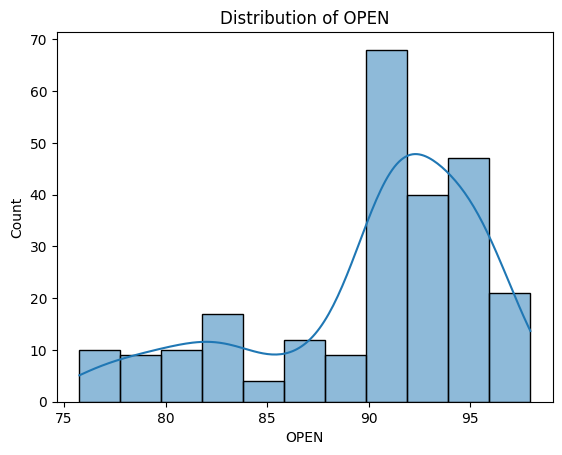

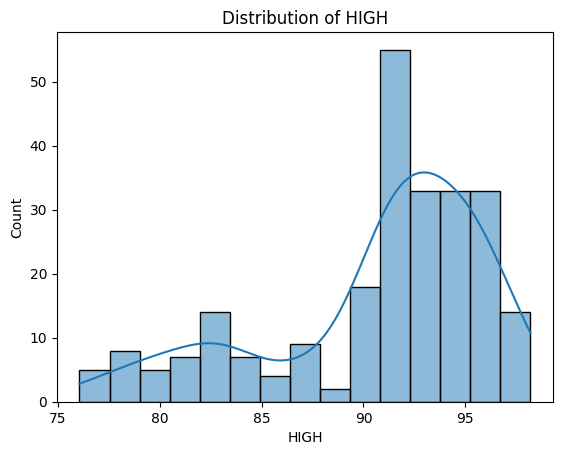

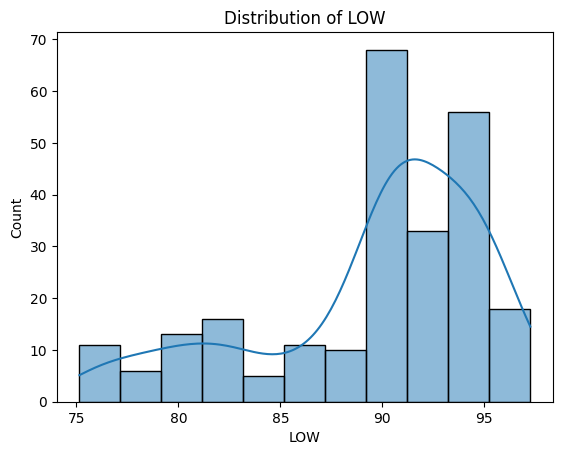

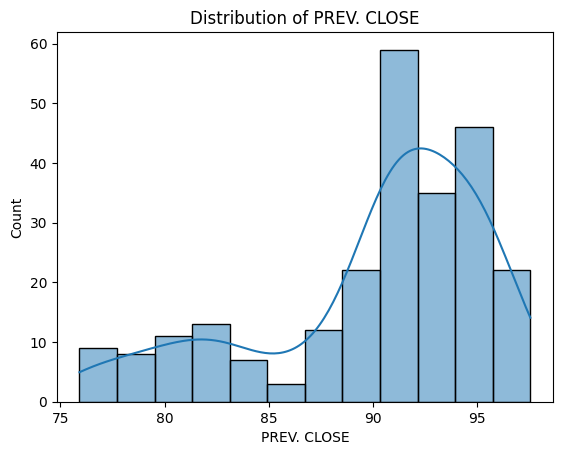

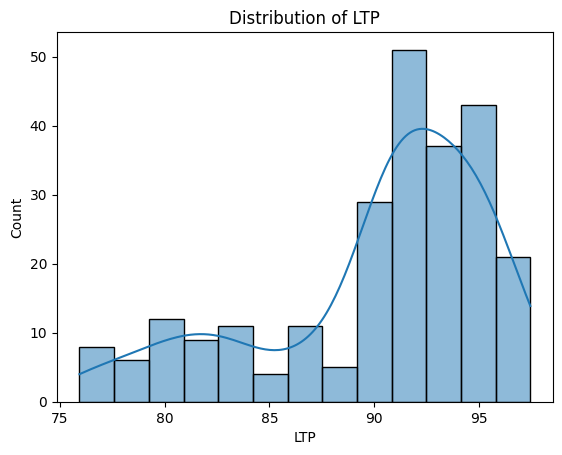

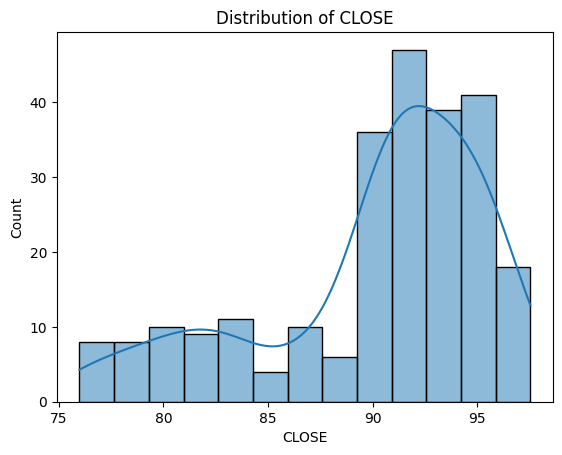

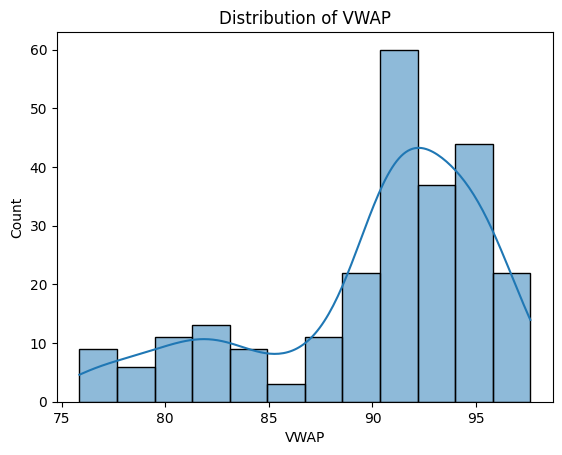

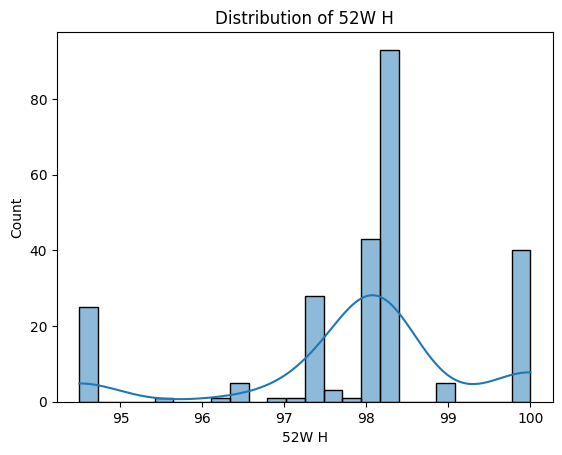

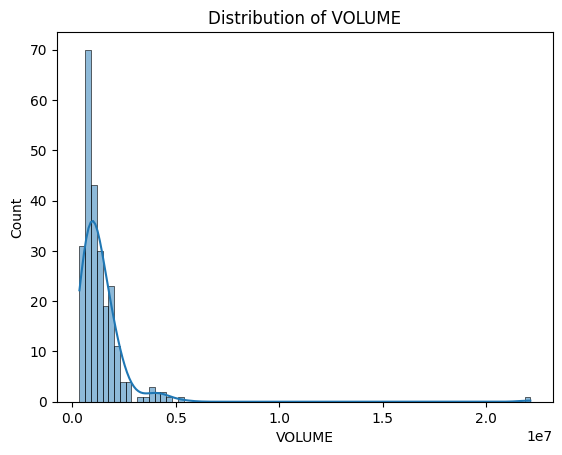

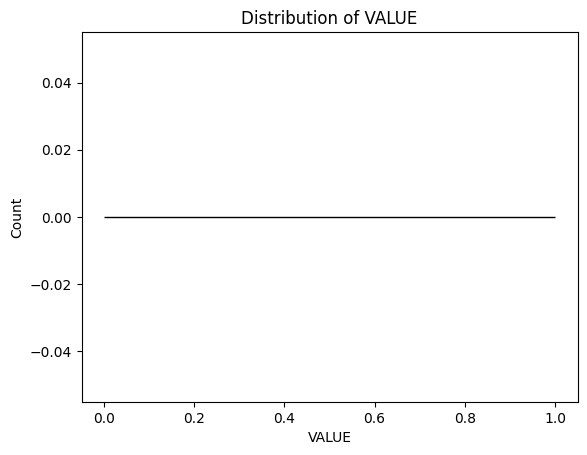

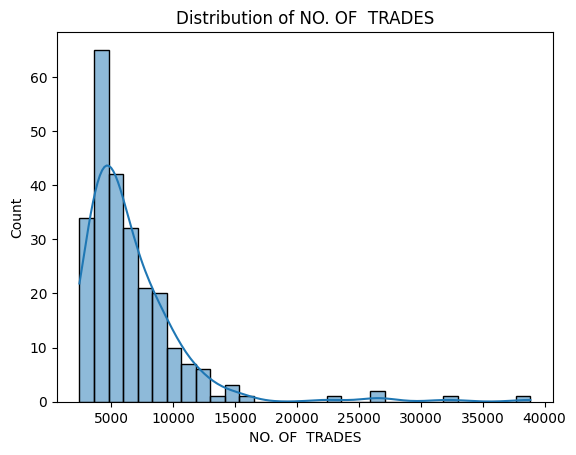

MissingDataError: exog contains inf or nans

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# ==============================
# 2. LOAD DATA
# ==============================
PGINVIT = pd.read_csv("Quote-Equity-PGINVIT-BL,IV-22-03-2025-22-03-2026.csv")

# ==============================
# 3. CLEAN COLUMN NAMES
# ==============================
PGINVIT.columns = PGINVIT.columns.str.strip()

# ==============================
# 4. HANDLE DATA TYPES
# ==============================
# Convert VALUE column
PGINVIT['VALUE'] = pd.to_numeric(PGINVIT['VALUE'], errors='coerce')

# Convert DATE
PGINVIT['DATE'] = pd.to_datetime(PGINVIT['DATE'], errors='coerce')

# ==============================
# 5. HANDLE MISSING VALUES
# ==============================
PGINVIT.fillna(PGINVIT.mean(numeric_only=True), inplace=True)

# ==============================
# 6. REMOVE USELESS COLUMNS
# ==============================
# Drop non-numeric / unnecessary
PGINVIT.drop(columns=['DATE', 'SERIES'], errors='ignore', inplace=True)

# Remove constant columns
for col in PGINVIT.columns:
    if PGINVIT[col].nunique() == 1:
        print("Dropping:", col)
        PGINVIT.drop(columns=[col], inplace=True)

# ==============================
# 7. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,6))
sns.heatmap(PGINVIT.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 8. LINEARITY CHECK (lmplot loop)
# ==============================
target = 'CLOSE'

for col in PGINVIT.columns:
    if col != target:
        sns.lmplot(x=col, y=target, data=PGINVIT)
        plt.title(f"{col} vs {target}")
        plt.show()

# ==============================
# 9. DISTRIBUTION CHECK
# ==============================
for col in PGINVIT.columns:
    sns.histplot(PGINVIT[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ==============================
# 10. DEFINE X and y
# ==============================
X = PGINVIT.drop(columns=[target])
y = PGINVIT[target]

# ==============================
# 11. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 12. MULTICOLLINEARITY (VIF)
# ==============================
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

# ==============================
# 13. TRAIN MODEL
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# 14. PREDICTION
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 15. EVALUATION
# ==============================
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# ==============================
# 16. RESIDUAL ANALYSIS
# ==============================
residuals = y_test - y_pred

# Residual plot
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Predicted")
plt.show()

# Normality check
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.show()

# ==============================
# 17. HOMOSCEDASTICITY TEST
# ==============================
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Homoscedasticity Check")
plt.show()

# ==============================
# 18. NORMALITY TEST (SHAPIRO)
# ==============================
stat, p = stats.shapiro(residuals)
print("Shapiro Test p-value:", p)

if p > 0.05:
    print("Residuals are Normal ✅")
else:
    print("Residuals are NOT Normal ❌")